In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv


c:\Users\Ansh\OneDrive\Desktop\Langraph\meraenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
# create an LLM model
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
)

In [3]:
# create a state
class BlogState(TypedDict):
    topic:str
    blog:str
    outline:str 
    marks:int

In [15]:
def outline(state:BlogState)-> BlogState:
    # get user query
    topic=state['topic']

    prompt = f"Write a detailed outline for this blog topic:{topic}"
    outline = llm.invoke(prompt).content
    state['outline'] = outline
    return state

In [5]:
def blog(state1:BlogState)->BlogState:
    #outline = state1['outline']
    prompt = f"Write a detailed blog using this topic and outline:{state1['topic']},{state1['outline']}"
    state1['blog'] = llm.invoke(prompt).content
    return state1

In [6]:
def evaluate(state:BlogState)->BlogState:
    prompt = f"Based on outline evaluate the blog content out of 10 in integer format:{state['outline']},{state['blog']}"
    state['marks'] = llm.invoke(prompt).content
    return state

In [17]:
# create a graph
graph=StateGraph(BlogState)

# create nodes
graph.add_node('outline',outline) 
graph.add_node('blog',blog)
graph.add_node('evaluate',evaluate) 

#create edges
graph.add_edge(START,'outline')
graph.add_edge('outline','blog')
graph.add_edge('blog','evaluate')
graph.add_edge('evaluate',END)

#compile the graph
workflow = graph.compile()

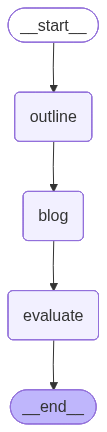

In [18]:
workflow

In [19]:
# run the graph
final_state = workflow.invoke({'topic': 'Generative Artificial Intelligence'})      #this statement will return state
print(final_state)

{'topic': 'Generative Artificial Intelligence', 'blog': '**Unlocking the Power of Generative Artificial Intelligence: A Comprehensive Guide**\n\n**Introduction**\n\nArtificial intelligence (AI) has been a rapidly evolving field for decades, with significant advancements in recent years. One of the most exciting and promising areas of AI research is generative artificial intelligence (AI). Generative AI has the potential to revolutionize various industries and transform the way we live and work. In this comprehensive guide, we will explore the concept of generative AI, its key features, applications, challenges, and future directions.\n\n**What is Generative Artificial Intelligence?**\n\nGenerative AI refers to a type of AI that can generate new data samples, images, music, or text that resemble existing data. This is achieved through the use of generative models, which are trained on large datasets to learn patterns and relationships between data points. Generative models can be catego

In [20]:
print(final_state['blog'])   # if you have to acces any specific key from the state

**Unlocking the Power of Generative Artificial Intelligence: A Comprehensive Guide**

**Introduction**

Artificial intelligence (AI) has been a rapidly evolving field for decades, with significant advancements in recent years. One of the most exciting and promising areas of AI research is generative artificial intelligence (AI). Generative AI has the potential to revolutionize various industries and transform the way we live and work. In this comprehensive guide, we will explore the concept of generative AI, its key features, applications, challenges, and future directions.

**What is Generative Artificial Intelligence?**

Generative AI refers to a type of AI that can generate new data samples, images, music, or text that resemble existing data. This is achieved through the use of generative models, which are trained on large datasets to learn patterns and relationships between data points. Generative models can be categorized into several types, including:

1. **Generative Adversarial

In [21]:
print(final_state['outline'])

**Title:** Unlocking the Power of Generative Artificial Intelligence: A Comprehensive Guide

**I. Introduction**

* Definition of Generative Artificial Intelligence (AI)
* Brief history of AI and its evolution
* Importance of Generative AI in modern applications
* Thesis statement: Generative AI has the potential to revolutionize various industries and transform the way we live and work.

**II. What is Generative Artificial Intelligence?**

* Explanation of the concept of generative models
* Types of generative models:
	+ Generative Adversarial Networks (GANs)
	+ Variational Autoencoders (VAEs)
	+ Generative Stochastic Networks (GSNs)
	+ Recurrent Neural Networks (RNNs)
* How generative models work
* Applications of generative models

**III. Key Features of Generative AI**

* Unsupervised learning: Generative AI can learn from data without labeled examples
* Data augmentation: Generative AI can generate new data samples that resemble existing data
* Anomaly detection: Generative AI can

In [22]:
print(final_state['marks'])

Based on the provided outline and content, I would rate the blog post out of 10 as 9.

Here's why:

1. **Comprehensive coverage**: The blog post covers a wide range of topics related to generative AI, including its definition, history, key features, applications, challenges, and future directions.
2. **Clear and concise writing**: The writing is clear, concise, and easy to understand, making it accessible to a broad audience.
3. **Well-organized structure**: The blog post follows a logical structure, with each section building on the previous one to provide a comprehensive overview of generative AI.
4. **Use of examples and illustrations**: The blog post uses examples and illustrations to help explain complex concepts, making it easier for readers to understand.
5. **Call to action**: The blog post includes a call to action, encouraging readers to learn more about generative AI, experiment with generative AI tools, join the generative AI community, and contribute to the development of 

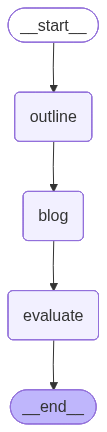

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png()) #"instead of using this library what if we direclty call workflow it is also printing"

In [24]:
from pprint import pprint
pprint(final_state, width=50, indent=2)

{ 'blog': '**Unlocking the Power of Generative '
          'Artificial Intelligence: A '
          'Comprehensive Guide**\n'
          '\n'
          '**Introduction**\n'
          '\n'
          'Artificial intelligence (AI) has been '
          'a rapidly evolving field for decades, '
          'with significant advancements in '
          'recent years. One of the most '
          'exciting and promising areas of AI '
          'research is generative artificial '
          'intelligence (AI). Generative AI has '
          'the potential to revolutionize '
          'various industries and transform the '
          'way we live and work. In this '
          'comprehensive guide, we will explore '
          'the concept of generative AI, its key '
          'features, applications, challenges, '
          'and future directions.\n'
          '\n'
          '**What is Generative Artificial '
          'Intelligence?**\n'
          '\n'
          'Generative AI refers to a type of AI '